## 1. Load the cleaned data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/matches_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,id,country,league,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR
0,1730,England,England Premier League,2008/2009,2008-08-16,Arsenal,West Bromwich Albion,1,0,H
1,1731,England,England Premier League,2008/2009,2008-08-16,Sunderland,Liverpool,0,1,A
2,1732,England,England Premier League,2008/2009,2008-08-16,West Ham United,Wigan Athletic,2,1,H
3,1734,England,England Premier League,2008/2009,2008-08-16,Everton,Blackburn Rovers,2,3,A
4,1735,England,England Premier League,2008/2009,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1,H


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              3040 non-null   int64         
 1   country         3040 non-null   object        
 2   league          3040 non-null   object        
 3   season          3040 non-null   object        
 4   date            3040 non-null   datetime64[ns]
 5   home_team       3040 non-null   object        
 6   away_team       3040 non-null   object        
 7   home_team_goal  3040 non-null   int64         
 8   away_team_goal  3040 non-null   int64         
 9   FTR             3040 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 237.6+ KB


In [4]:
df['country'].value_counts()

country
England    3040
Name: count, dtype: int64

In [5]:
df['league'].value_counts()

league
England Premier League    3040
Name: count, dtype: int64

## 2. Drop columns that never change

In [11]:
df = df.drop(columns=['country', 'league'])
df.head(20)

,id,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR
0,1730,2008/2009,2008-08-16,Arsenal,West Bromwich Albion,1,0,H
1,1731,2008/2009,2008-08-16,Sunderland,Liverpool,0,1,A
2,1732,2008/2009,2008-08-16,West Ham United,Wigan Athletic,2,1,H
3,1734,2008/2009,2008-08-16,Everton,Blackburn Rovers,2,3,A
4,1735,2008/2009,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1,H
5,1736,2008/2009,2008-08-16,Bolton Wanderers,Stoke City,3,1,H
6,1737,2008/2009,2008-08-16,Hull City,Fulham,2,1,H
7,1729,2008/2009,2008-08-17,Manchester United,Newcastle United,1,1,D
8,1733,2008/2009,2008-08-17,Aston Villa,Manchester City,4,2,H
9,1738,2008/2009,2008-08-17,Chelsea,Portsmouth,4,0,H


In [13]:
def get_points(goals_for, goals_against):
    if goals_for > goals_against:
        return 3
    elif goals_for == goals_against:
        return 1
    else:
        return 0

# Build a "long" table: one row per team per match
home_long = df[['id','date','home_team','home_team_goal','away_team_goal']].copy()
home_long.columns = ['id','date','team','goals_for','goals_against']
home_long['venue'] = 'H'

away_long = df[['id','date','away_team','away_team_goal','home_team_goal']].copy()
away_long.columns = ['id','date','team','goals_for','goals_against']
away_long['venue'] = 'A'

team_long = pd.concat([home_long, away_long]).sort_values(['team','date']).reset_index(drop=True)
team_long['points'] = team_long.apply(lambda r: get_points(r['goals_for'], r['goals_against']), axis=1)

# Rolling form: average points over the last 5 matches, using only PAST matches (shift(1))
team_long['form_last5'] = (
    team_long.groupby('team')['points']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

team_long[['team','date','points','form_last5']].head(10)

,team,date,points,form_last5
0,Arsenal,2008-08-16,3,NaN
1,Arsenal,2008-08-23,0,3.00
2,Arsenal,2008-08-30,3,1.50
3,Arsenal,2008-09-13,3,2.00
4,Arsenal,2008-09-20,3,2.25
5,Arsenal,2008-09-27,0,2.40
6,Arsenal,2008-10-04,1,1.80
7,Arsenal,2008-10-18,3,2.00
8,Arsenal,2008-10-26,3,2.00
9,Arsenal,2008-10-29,1,2.00


In [14]:
df.head()

,id,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR
0,1730,2008/2009,2008-08-16,Arsenal,West Bromwich Albion,1,0,H
1,1731,2008/2009,2008-08-16,Sunderland,Liverpool,0,1,A
2,1732,2008/2009,2008-08-16,West Ham United,Wigan Athletic,2,1,H
3,1734,2008/2009,2008-08-16,Everton,Blackburn Rovers,2,3,A
4,1735,2008/2009,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1,H


In [17]:
home_only = team_long[team_long['venue'] == 'H'].sort_values(['team','date']).copy()
home_only['home_form_last5'] = (
    home_only.groupby('team')['points']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
home_only = home_only[['id','team','home_form_last5']]

In [19]:
df.head()

,id,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR
0,1730,2008/2009,2008-08-16,Arsenal,West Bromwich Albion,1,0,H
1,1731,2008/2009,2008-08-16,Sunderland,Liverpool,0,1,A
2,1732,2008/2009,2008-08-16,West Ham United,Wigan Athletic,2,1,H
3,1734,2008/2009,2008-08-16,Everton,Blackburn Rovers,2,3,A
4,1735,2008/2009,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1,H


In [21]:
df = df.sort_values('date').reset_index(drop=True)

# consistent pair label, regardless of who is home
df['team_a'] = np.where(df['home_team'] < df['away_team'], df['home_team'], df['away_team'])
df['team_b'] = np.where(df['home_team'] < df['away_team'], df['away_team'], df['home_team'])
df['matchup'] = df['team_a'] + '_' + df['team_b']

a_is_home = df['home_team'] == df['team_a']
home_pts = df['FTR'].map({'H': 3, 'D': 1, 'A': 0})
away_pts = df['FTR'].map({'H': 0, 'D': 1, 'A': 3})
df['a_pts'] = np.where(a_is_home, home_pts, away_pts)
df['b_pts'] = np.where(a_is_home, away_pts, home_pts)

# average points in PAST meetings only (shift(1) excludes the current match)
for c in ['a_pts', 'b_pts']:
    df['prev_' + c] = df.groupby('matchup')[c].transform(lambda x: x.shift(1).expanding().mean())

df['h2h_home_pts'] = np.where(a_is_home, df['prev_a_pts'], df['prev_b_pts'])
df = df.drop(columns=['team_a','team_b','a_pts','b_pts','prev_a_pts','prev_b_pts','h2h_home_win_rate'], errors='ignore')

In [22]:
df.head()

,id,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR,matchup,h2h_home_pts
0,1730,2008/2009,2008-08-16,Arsenal,West Bromwich Albion,1,0,H,Arsenal_West Bromwich Albion,NaN
1,1731,2008/2009,2008-08-16,Sunderland,Liverpool,0,1,A,Liverpool_Sunderland,NaN
2,1732,2008/2009,2008-08-16,West Ham United,Wigan Athletic,2,1,H,West Ham United_Wigan Athletic,NaN
3,1734,2008/2009,2008-08-16,Everton,Blackburn Rovers,2,3,A,Blackburn Rovers_Everton,NaN
4,1735,2008/2009,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1,H,Middlesbrough_Tottenham Hotspur,NaN


In [25]:
# goal difference per match, then rolling average of the last 5 (past matches only)
team_long['gd'] = team_long['goals_for'] - team_long['goals_against']
team_long['gd_last5'] = team_long.groupby('team')['gd'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# venue-specific form: grouping by team AND venue means home rows use only home games,
# and away rows use only away games
team_long['venue_form'] = team_long.groupby(['team', 'venue'])['points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# split back into home-side and away-side tables
home_feats = team_long[team_long['venue'] == 'H'][['id', 'team', 'form_last5', 'venue_form', 'gd_last5']]
home_feats.columns = ['id', 'home_team', 'home_form_last5_overall', 'home_venue_form', 'home_gd_last5']

away_feats = team_long[team_long['venue'] == 'A'][['id', 'team', 'form_last5', 'venue_form', 'gd_last5']]
away_feats.columns = ['id', 'away_team', 'away_form_last5_overall', 'away_venue_form', 'away_gd_last5']

df = df.merge(home_feats, on=['id', 'home_team'], how='left')
df = df.merge(away_feats, on=['id', 'away_team'], how='left')

print(df.shape)   # must still be 3040 rows
df.head(10)

(3040, 16)


,id,season,date,home_team,away_team,home_team_goal,away_team_goal,FTR,matchup,h2h_home_pts,home_form_last5_overall,home_venue_form,home_gd_last5,away_form_last5_overall,away_venue_form,away_gd_last5
0,1730,2008/2009,2008-08-16,Arsenal,West Bromwich Albion,1,0,H,Arsenal_West Bromwich Albion,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1731,2008/2009,2008-08-16,Sunderland,Liverpool,0,1,A,Liverpool_Sunderland,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1732,2008/2009,2008-08-16,West Ham United,Wigan Athletic,2,1,H,West Ham United_Wigan Athletic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1734,2008/2009,2008-08-16,Everton,Blackburn Rovers,2,3,A,Blackburn Rovers_Everton,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1735,2008/2009,2008-08-16,Middlesbrough,Tottenham Hotspur,2,1,H,Middlesbrough_Tottenham Hotspur,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1736,2008/2009,2008-08-16,Bolton Wanderers,Stoke City,3,1,H,Bolton Wanderers_Stoke City,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1737,2008/2009,2008-08-16,Hull City,Fulham,2,1,H,Fulham_Hull City,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1729,2008/2009,2008-08-17,Manchester United,Newcastle United,1,1,D,Manchester United_Newcastle United,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1733,2008/2009,2008-08-17,Aston Villa,Manchester City,4,2,H,Aston Villa_Manchester City,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1738,2008/2009,2008-08-17,Chelsea,Portsmouth,4,0,H,Chelsea_Portsmouth,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
import sqlite3
conn = sqlite3.connect('../data/raw/database.sqlite')
team_attrs = pd.read_sql("SELECT * FROM Team_Attributes", conn)
teams = pd.read_sql("SELECT team_api_id, team_long_name FROM Team", conn)
conn.close()

team_attrs = team_attrs.merge(teams, on='team_api_id')
team_attrs['date'] = pd.to_datetime(team_attrs['date'])

# Keep it simple: one overall strength score per team per attribute date
team_attrs['squad_strength'] = team_attrs[['buildUpPlaySpeed','buildUpPlayPassing',
                                            'chanceCreationPassing','chanceCreationShooting',
                                            'defencePressure','defenceAggression']].mean(axis=1)

team_attrs = team_attrs[['team_long_name','date','squad_strength']].sort_values(['team_long_name','date'])
team_attrs.head()

,team_long_name,date,squad_strength
630,1. FC Kaiserslautern,2010-02-22,59.166667
631,1. FC Kaiserslautern,2011-02-22,46.333333
632,1. FC Kaiserslautern,2012-02-22,47.833333
633,1. FC Kaiserslautern,2013-09-20,52.000000
634,1. FC Kaiserslautern,2014-09-19,53.000000


In [29]:
import sqlite3
conn = sqlite3.connect('../data/raw/database.sqlite')
team_attrs = pd.read_sql("SELECT * FROM Team_Attributes", conn)
teams = pd.read_sql("SELECT team_api_id, team_long_name FROM Team", conn)
conn.close()

team_attrs = team_attrs.merge(teams, on='team_api_id')
team_attrs['date'] = pd.to_datetime(team_attrs['date'])
team_attrs['squad_strength'] = team_attrs[['buildUpPlaySpeed', 'buildUpPlayPassing',
                                            'chanceCreationPassing', 'chanceCreationShooting',
                                            'defencePressure', 'defenceAggression']].mean(axis=1)
ta = team_attrs[['team_long_name', 'date', 'squad_strength']].sort_values('date')

df = df.sort_values('date').reset_index(drop=True)

# most recent rating dated on or before each match (backward only, so no future info)
home_attr = ta.rename(columns={'team_long_name': 'home_team', 'squad_strength': 'home_squad_strength', 'date': 'attr_date'})
df = pd.merge_asof(df, home_attr, left_on='date', right_on='attr_date', by='home_team', direction='backward')
df = df.drop(columns='attr_date')

away_attr = ta.rename(columns={'team_long_name': 'away_team', 'squad_strength': 'away_squad_strength', 'date': 'attr_date'})
df = pd.merge_asof(df, away_attr, left_on='date', right_on='attr_date', by='away_team', direction='backward')
df = df.drop(columns='attr_date')

print('Before fill:')
print(df[['home_squad_strength', 'away_squad_strength']].isna().sum())

# matches played before a team's first rating: borrow that team's earliest rating (log as a limitation)
first_attr = ta.groupby('team_long_name')['squad_strength'].first()
df['home_squad_strength'] = df['home_squad_strength'].fillna(df['home_team'].map(first_attr))
df['away_squad_strength'] = df['away_squad_strength'].fillna(df['away_team'].map(first_attr))

print('After fill:')
print(df[['home_squad_strength', 'away_squad_strength']].isna().sum())

Before fill:
home_squad_strength    644
away_squad_strength    644
dtype: int64
After fill:
home_squad_strength    0
away_squad_strength    0
dtype: int64


In [31]:
print(df.shape)
print(df.isna().sum())

(3040, 18)
id                           0
season                       0
date                         0
home_team                    0
away_team                    0
home_team_goal               0
away_team_goal               0
FTR                          0
matchup                      0
h2h_home_pts               466
home_form_last5_overall     16
home_venue_form             34
home_gd_last5               16
away_form_last5_overall     18
away_venue_form             34
away_gd_last5               18
home_squad_strength          0
away_squad_strength          0
dtype: int64


In [33]:
df = df.drop(columns=['matchup'], errors='ignore')

# flag: was there any past meeting? (the NaN itself carries meaning, so keep that information)
df['h2h_available'] = df['h2h_home_pts'].notna().astype(int)

# differences: home minus away
df['form_diff'] = df['home_form_last5_overall'] - df['away_form_last5_overall']
df['venue_form_diff'] = df['home_venue_form'] - df['away_venue_form']
df['gd_diff'] = df['home_gd_last5'] - df['away_gd_last5']
df['strength_diff'] = df['home_squad_strength'] - df['away_squad_strength']

# target: A=0, D=1, H=2
df['target'] = df['FTR'].map({'A': 0, 'D': 1, 'H': 2})

features = [
    'home_form_last5_overall', 'away_form_last5_overall',
    'home_venue_form', 'away_venue_form',
    'home_gd_last5', 'away_gd_last5',
    'h2h_home_pts', 'h2h_available',
    'home_squad_strength', 'away_squad_strength',
    'form_diff', 'venue_form_diff', 'gd_diff', 'strength_diff'
]
print(len(features), 'features')

14 features


In [35]:
# 1. No outcome columns among the features
outcome_cols = {'home_team_goal', 'away_team_goal', 'FTR', 'target'}
assert not outcome_cols & set(features), 'Outcome column found in features!'

# 2. Opening-day matches must have NO form history (proves shift(1) works)
first_day = df[df['date'] == df['date'].min()]
assert first_day['home_form_last5_overall'].isna().all(), 'Form leaks current match!'
assert first_day['away_form_last5_overall'].isna().all(), 'Form leaks current match!'
assert first_day['h2h_home_pts'].isna().all(), 'H2H leaks current match!'

# 3. Manual spot-check: Arsenal's 2nd match form should equal their 1st match points (3.0)
arsenal = df[(df['home_team'] == 'Arsenal') | (df['away_team'] == 'Arsenal')].head(3)
print(arsenal[['date', 'home_team', 'away_team', 'FTR',
               'home_form_last5_overall', 'away_form_last5_overall']])

print('Leakage checks passed')

         date home_team             away_team FTR  home_form_last5_overall  \
0  2008-08-16   Arsenal  West Bromwich Albion   H                      NaN   
14 2008-08-23    Fulham               Arsenal   H                      0.0   
20 2008-08-30   Arsenal      Newcastle United   H                      1.5   

    away_form_last5_overall  
0                       NaN  
14                      3.0  
20                      2.0  
Leakage checks passed


In [37]:
train = df[df['season'] <= '2012/2013'].copy()                     # 5 seasons: 2008/09 to 2012/13
val   = df[df['season'].isin(['2013/2014', '2014/2015'])].copy()   # 2 seasons, for tuning in Part 3
test  = df[df['season'] == '2015/2016'].copy()                     # 1 season, sealed until Part 4

print('Train:', train.shape, train['date'].min().date(), 'to', train['date'].max().date())
print('Val:  ', val.shape, val['date'].min().date(), 'to', val['date'].max().date())
print('Test: ', test.shape, test['date'].min().date(), 'to', test['date'].max().date())

assert train['date'].max() < val['date'].min() < test['date'].min(), 'Splits overlap in time!'

Train: (1900, 23) 2008-08-16 to 2013-05-19
Val:   (760, 23) 2013-08-17 to 2015-05-24
Test:  (380, 23) 2015-08-08 to 2016-05-17


In [39]:
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(name, part['FTR'].value_counts(normalize=True).round(3).to_dict())

train {'H': 0.464, 'A': 0.27, 'D': 0.266}
val {'H': 0.462, 'A': 0.313, 'D': 0.225}
test {'H': 0.413, 'A': 0.305, 'D': 0.282}


In [41]:
train_means = train[features].mean()

for part in (train, val, test):
    part[features] = part[features].fillna(train_means)

print(train[features].isna().sum().sum(), val[features].isna().sum().sum(), test[features].isna().sum().sum())

0 0 0


In [43]:
# correlation of each feature with the target (training data only)
corr = train[features + ['target']].corr()['target'].drop('target').sort_values()
print(corr.round(3))

away_gd_last5             -0.163
away_venue_form           -0.159
away_form_last5_overall   -0.139
strength_diff             -0.126
home_squad_strength       -0.047
h2h_available              0.021
away_squad_strength        0.115
home_form_last5_overall    0.172
home_venue_form            0.174
home_gd_last5              0.188
h2h_home_pts               0.200
form_diff                  0.225
venue_form_diff            0.240
gd_diff                    0.253
Name: target, dtype: float64


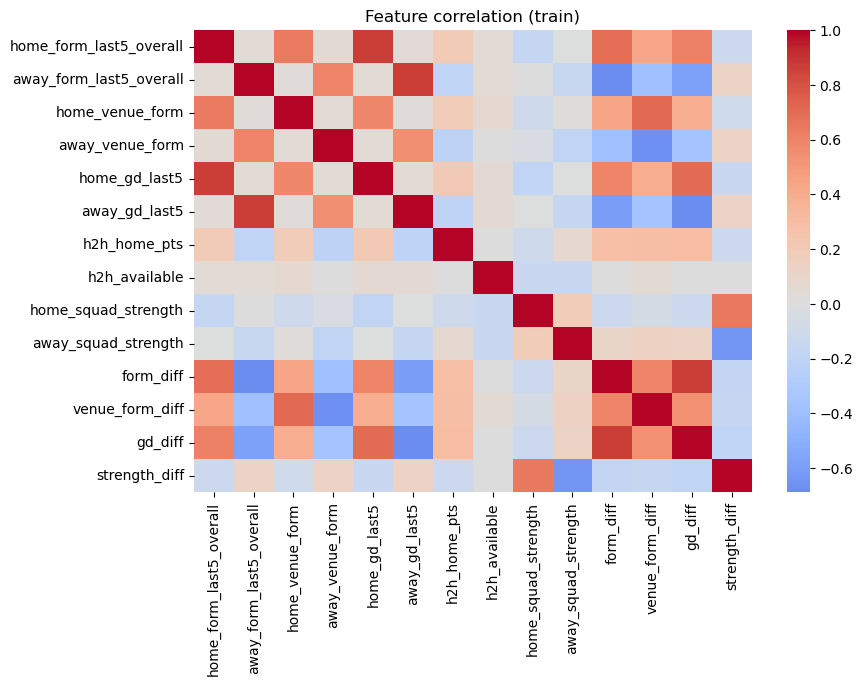

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.heatmap(train[features].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature correlation (train)')
plt.show()

In [46]:
keep = ['id', 'date', 'season', 'home_team', 'away_team'] + features + ['FTR', 'target']

train[keep].to_csv('../data/processed/train.csv', index=False)
val[keep].to_csv('../data/processed/val.csv', index=False)
test[keep].to_csv('../data/processed/test.csv', index=False)

# also save the feature list so Part 3 uses exactly the same columns
pd.Series(features).to_csv('../data/processed/feature_list.csv', index=False, header=['feature'])
print('Saved')

Saved


### Preprocessing & Feature Log (Part 2)

| Topic | Decision | Reason |
|---|---|---|
| Dropped columns | country, league, matchup (helper) | Constant after filtering to England / helper only |
| id, team names | Kept for reference only, not model inputs | ~30 teams would add many sparse columns; form and strength already capture team quality |
| Outliers | Kept (e.g. 9-goal match) | Genuine results, not errors |
| Rolling form | Mean points of last 5 matches, shift(1) | Captures momentum, excludes current match |
| Venue form | Last 5 home games (home team) / last 5 away games (away team) | Teams perform differently at home and away |
| Goal-difference form | Mean goal difference, last 5 | Shows how convincing wins/losses are |
| Head-to-head | Mean points the home team earned in past meetings, shift(1) | Captures pair-specific history |
| H2H missing (first meeting) | Flag `h2h_available` + train-mean fill | Keeps the information that no history existed |
| Squad strength | Mean of 6 Team_Attributes ratings, latest rating on/before match date (merge_asof backward) | Quality signal independent of results |
| Early squad ratings (644 matches) | Filled with team's earliest rating | Limitation: borrows a slightly later rating |
| Difference features | form, venue form, goal diff, strength (home minus away) | Easier for models to use than two raw columns |
| Betting odds | Excluded | Would largely copy the bookmaker's prediction |
| Target | A=0, D=1, H=2 | Required by some models |
| Split | Chronological: train 2008/09-2012/13, val 2013/14-2014/15, test 2015/16 sealed | Prevents the model training on the future |
| Missing values | Filled with training means only | Avoids test-to-train leakage |
| Scaling | Deferred to Part 3, inside a pipeline fitted on train only | Only LR/KNN/SVM need it; scaling before the split would leak |
| Imbalance | class_weight='balanced' in Part 3, no SMOTE | Moderate imbalance; synthetic matches are not realistic |
| Leakage controls | shift(1) on all rolling features, backward-only rating merge, chronological split, assertion checks | |